In [1]:
!pip install codecarbon

In [2]:
!pip uninstall -y dask distributed
!pip install lightgbm dask distributed

Found existing installation: dask 2026.1.2
Uninstalling dask-2026.1.2:
  Successfully uninstalled dask-2026.1.2
Found existing installation: distributed 2026.1.2
Uninstalling distributed-2026.1.2:
  Successfully uninstalled distributed-2026.1.2
  Using cached dask-2026.1.2-py3-none-any.whl.metadata (3.8 kB)
  Using cached distributed-2026.1.2-py3-none-any.whl.metadata (3.4 kB)
Using cached dask-2026.1.2-py3-none-any.whl (1.5 MB)
Using cached distributed-2026.1.2-py3-none-any.whl (1.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rapids-dask-dependency 26.2.0 requires dask==2026.1.1, but you have dask 2026.1.2 which is incompatible.
rapids-dask-dependency 26.2.0 requires distributed==2026.1.1, but you have distributed 2026.1.2 which is incompatible.


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, brier_score_loss, roc_auc_score

)
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from codecarbon import EmissionsTracker

In [4]:
dataset = pd.read_csv('/content/drive/MyDrive/Pesquisa 2/Código/Bondora/[BONDORA]preprocessed_database.csv')

In [5]:
dataset

,BidsPortfolioManager,BidsApi,BidsManual,Age,AppliedAmount,Interest,LoanDuration,IncomeFromPrincipalEmployer,IncomeFromPension,IncomeFromFamilyAllowance,...,HomeOwnershipType_2.0,HomeOwnershipType_3.0,HomeOwnershipType_4.0,HomeOwnershipType_5.0,HomeOwnershipType_6.0,HomeOwnershipType_7.0,HomeOwnershipType_8.0,HomeOwnershipType_9.0,HomeOwnershipType_10.0,NewCreditCustomer_True
0,970,1150,5.0,53,2125.0,20.97,60,0.0,301.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,1295,0,1705.0,50,3000.0,17.12,60,900.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,2700,565,5835.0,44,10630.0,13.67,60,600.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,1
3,1115,0,385.0,42,1500.0,40.40,60,863.0,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
4,305,0,785.0,34,1595.0,68.39,48,0.0,697.0,0.0,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121456,2000,0,0.0,38,2000.0,33.79,60,1500.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,1
121457,6215,70,1155.0,37,7440.0,24.52,60,2172.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
121458,430,0,1055.0,37,1595.0,64.51,60,1550.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
121459,3000,0,0.0,58,3000.0,21.62,60,350.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1


In [6]:
dataset.describe()

,BidsPortfolioManager,BidsApi,BidsManual,Age,AppliedAmount,Interest,LoanDuration,IncomeFromPrincipalEmployer,IncomeFromPension,IncomeFromFamilyAllowance,...,HomeOwnershipType_2.0,HomeOwnershipType_3.0,HomeOwnershipType_4.0,HomeOwnershipType_5.0,HomeOwnershipType_6.0,HomeOwnershipType_7.0,HomeOwnershipType_8.0,HomeOwnershipType_9.0,HomeOwnershipType_10.0,NewCreditCustomer_True
count,121461.000000,121461.000000,121461.000000,121461.000000,121461.000000,121461.000000,121461.000000,121461.000000,121461.000000,121461.000000,...,121461.000000,121461.000000,121461.000000,121461.000000,121461.000000,121461.000000,121461.000000,121461.000000,121461.000000,121461.000000
mean,963.968270,29.737652,543.546900,39.990993,2723.155439,38.126434,45.933435,471.018230,20.231129,5.953645,...,0.174682,0.232206,0.035830,0.009913,0.012490,0.024592,0.110414,0.005483,0.059649,0.607355
std,1363.794909,153.663101,756.765106,12.326199,2371.562360,26.750151,15.810164,1871.670509,157.310574,39.495278,...,0.379696,0.422242,0.185868,0.099068,0.111057,0.154880,0.313406,0.073846,0.236836,0.488341
min,0.000000,0.000000,0.000000,0.000000,10.000000,2.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,145.000000,0.000000,69.000000,30.000000,740.000000,22.200000,36.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,456.000000,0.000000,294.000000,38.000000,2125.000000,32.140000,48.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,1229.000000,5.000000,706.000000,49.000000,4150.000000,45.280000,60.000000,450.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,10625.000000,7570.000000,10630.000000,77.000000,10632.000000,264.310000,60.000000,228400.000000,5038.000000,2006.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
dataset['Status']

,Status
0,1
1,1
2,0
3,1
4,1
...,...
121456,1
121457,0
121458,0
121459,0


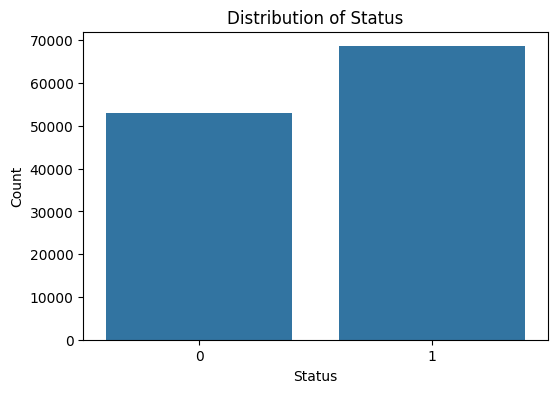

In [8]:
#plotando a classe
plt.figure(figsize=(6, 4))
sns.countplot(x='Status', data=dataset)
plt.title('Distribution of Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

In [9]:
y = dataset['Status']
y

,Status
0,1
1,1
2,0
3,1
4,1
...,...
121456,1
121457,0
121458,0
121459,0


In [10]:
X = dataset.drop('Status', axis=1)
X

,BidsPortfolioManager,BidsApi,BidsManual,Age,AppliedAmount,Interest,LoanDuration,IncomeFromPrincipalEmployer,IncomeFromPension,IncomeFromFamilyAllowance,...,HomeOwnershipType_2.0,HomeOwnershipType_3.0,HomeOwnershipType_4.0,HomeOwnershipType_5.0,HomeOwnershipType_6.0,HomeOwnershipType_7.0,HomeOwnershipType_8.0,HomeOwnershipType_9.0,HomeOwnershipType_10.0,NewCreditCustomer_True
0,970,1150,5.0,53,2125.0,20.97,60,0.0,301.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,1295,0,1705.0,50,3000.0,17.12,60,900.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,2700,565,5835.0,44,10630.0,13.67,60,600.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,1
3,1115,0,385.0,42,1500.0,40.40,60,863.0,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
4,305,0,785.0,34,1595.0,68.39,48,0.0,697.0,0.0,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121456,2000,0,0.0,38,2000.0,33.79,60,1500.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,1
121457,6215,70,1155.0,37,7440.0,24.52,60,2172.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
121458,430,0,1055.0,37,1595.0,64.51,60,1550.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
121459,3000,0,0.0,58,3000.0,21.62,60,350.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1


In [11]:
print(X.shape, y.shape)

(121461, 103) (121461,)


In [12]:
colunas_originais = X.columns

In [13]:
scaler = StandardScaler()
scaler.fit(X)
X=scaler.transform(X)

X = pd.DataFrame(X, columns=colunas_originais)
print(X)

        BidsPortfolioManager   BidsApi  BidsManual       Age  AppliedAmount  \
0                   0.004423  7.290410   -0.711646  1.055399      -0.252221   
1                   0.242729 -0.193526    1.534767  0.812014       0.116736   
2                   1.272947  3.483364    6.992229  0.325244       3.334037   
3                   0.110744 -0.193526   -0.209507  0.162987      -0.515761   
4                  -0.483189 -0.193526    0.319061 -0.486039      -0.475703   
...                      ...       ...         ...       ...            ...   
121456              0.759671 -0.193526   -0.718253 -0.161526      -0.304929   
121457              3.850325  0.262018    0.807986 -0.242654       1.988927   
121458             -0.391533 -0.193526    0.675844 -0.242654      -0.475703   
121459              1.492923 -0.193526   -0.718253  1.461041       0.116736   
121460             -0.706831 -0.193526    0.999592  1.947811      -0.600094   

        Interest  LoanDuration  IncomeFromPrincipal

In [14]:
# Cálculo do MI Score
mi_scores = mutual_info_classif(X, y)

# Ranking crescente (menor MI = menos informativa)
mi_ranking = pd.Series(mi_scores, index=X.columns).sort_values(ascending=True)

# Exibir top e bottom features
display(mi_ranking.head(10))   # 10 menos relevantes
display(mi_ranking.tail(10))   # 10 mais relevantes

,0
UseOfLoan_1,0.0
UseOfLoan_108,0.0
UseOfLoan_107,0.0
UseOfLoan_110,0.0
LanguageCode_13,0.0
LanguageCode_21,0.0
LanguageCode_10,0.0
EmploymentStatus_4.0,0.0
HomeOwnershipType_5.0,0.0
HomeOwnershipType_9.0,0.0


,0
FreeCash,0.022128
BidsPortfolioManager,0.026170
EmploymentStatus_3.0,0.026263
IncomeTotal,0.029451
BidsManual,0.029912
IncomeFromPrincipalEmployer,0.033337
AppliedAmount,0.040504
LoanDuration,0.048492
Interest,0.054656
LossGivenDefault,0.066983


In [ ]:
percentuais = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
resultados = []

In [ ]:
def run_experimento(modelo_nome, model, X_train, X_val, y_train, y_val, return_preds=False):
    print(f"\nTreinando modelo: {modelo_nome}...")

    tracker = EmissionsTracker()
    tracker.start()
    start_time = time.time()

    try:
        if modelo_nome == 'RNA':
            model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)
            y_pred_proba = model.predict(X_val).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            if hasattr(model, "predict_proba"):
                y_pred_proba = model.predict_proba(X_val)[:, 1]
            elif hasattr(model, "decision_function"):
                y_pred_proba = 1 / (1 + np.exp(-model.decision_function(X_val)))
            else:
                y_pred_proba = np.clip(y_pred.astype(float), 0, 1)

    finally:
        emissions_kg = tracker.stop()
        emissions_g = emissions_kg * 1000
        energia = tracker._total_energy.kWh
        tempo = time.time() - start_time

    # Métricas clássicas
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    brier = brier_score_loss(y_val, y_pred_proba)
    auc = roc_auc_score(y_val, y_pred_proba) if len(np.unique(y_val)) == 2 else np.nan

    # Métrica ambiental
    rga = emissions_g / acc if acc > 0 else float('inf')

    print(f"{modelo_nome} concluído.")
    print(f"Acurácia: {acc:.4f} | Precisão: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(f"AUC: {auc:.4f} | Brier: {brier:.6f}")
    print(f"Energia: {energia:.6f} kWh | Emissões: {emissions_g:.6f} gCO₂eq")
    print(f"RGA: {rga:.6f} | Tempo: {tempo:.2f}s\n")

    if return_preds:
        return (
            acc, prec, rec, f1, brier, auc,
            tempo, emissions_g, energia, rga,
            y_pred, y_pred_proba
        )
    else:
        return acc, prec, rec, f1, brier, auc, tempo, emissions_g, energia, rga


In [ ]:
for p in percentuais:
    print(f"Redução de {int(p*100)}%:")

    n_remove = int(len(mi_ranking) * p)
    cols_reduzido = mi_ranking.index[n_remove:]
    X_reduz = X[cols_reduzido]

    print(f"Antes: {X.shape[1]} features")
    print(f"Removidas: {n_remove}")
    print(f"Depois: {X_reduz.shape[1]} features")

    X_train, X_val, y_train, y_val = train_test_split(
        X_reduz, y, test_size=0.3, random_state=10
    )

    modelos = {
        "RandomForest": RandomForestClassifier(n_estimators=30, random_state=10),
        "LightGBM": LGBMClassifier(n_estimators=30, random_state=10),
        "RNA": Sequential([
            Dense(64, input_dim=X_train.shape[1], activation='relu'),
            Dense(32, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
    }

    for nome, modelo in modelos.items():
        if nome == "RNA":
            modelo.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

        acc, prec, rec, f1, brier, auc, tempo, em, energia, rga, y_pred, y_prob = run_experimento(
            nome, modelo, X_train, X_val, y_train, y_val, return_preds=True
        )

        f1 = f1_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred)
        brier = brier_score_loss(y_val, y_prob)
        auc = roc_auc_score(y_val, y_prob)
        rga = em / acc if acc > 0 else float('inf')

        resultados.append([
            nome,
            f"-{int(p*100)}%",
            X_reduz.shape[1],
            acc,
            prec,
            rec,
            f1,
            brier,
            auc,
            tempo,
            energia,
            em,
            rga
        ])

print("Todos os experimentos finalizados!\n")


Redução de 0%:
Antes: 103 features
Removidas: 0
Depois: 103 features


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[codecarbon WARNING @ 18:10:08] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:10:09] [setup] RAM Tracking...
[codecarbon INFO @ 18:10:09] [setup] CPU Tracking...
[codecarbon WARNING @ 18:10:09] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 18:10:09] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 18:10:09] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.


Treinando modelo: RandomForest...


[codecarbon INFO @ 18:10:09] >>> Tracker's metadata:
[codecarbon INFO @ 18:10:09]   Platform system: Linux-6.6.113+-x86_64-with-glibc2.35
[codecarbon INFO @ 18:10:09]   Python version: 3.12.12
[codecarbon INFO @ 18:10:09]   CodeCarbon version: 3.2.3
[codecarbon INFO @ 18:10:09]   Available RAM : 12.671 GB
[codecarbon INFO @ 18:10:09]   CPU count: 2 thread(s) in 1 physical CPU(s)
[codecarbon INFO @ 18:10:09]   CPU model: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon INFO @ 18:10:09]   GPU count: 1
[codecarbon INFO @ 18:10:09]   GPU model: 1 x Tesla T4
[codecarbon INFO @ 18:10:09] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 18:10:24] Energy consumed for RAM : 0.000042 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:10:24] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:10:24] Energy consumed for All CPU : 0.000177 kWh
[codecarbon INFO @ 18:10:24] Energy consumed for all GPUs : 0.000125 kWh. Total GPU 

RandomForest concluído.
Acurácia: 0.7036 | Precisão: 0.7106 | Recall: 0.7997 | F1: 0.7525
AUC: 0.7549 | Brier: 0.195202
Energia: 0.000390 kWh | Emissões: 0.183414 gCO₂eq
RGA: 0.260694 | Tempo: 17.00s


Treinando modelo: LightGBM...


[codecarbon INFO @ 18:10:27] Emissions data (if any) will be saved to file /content/emissions.csv


[LightGBM] [Info] Number of positive: 48035, number of negative: 36987
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.074384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4341
[LightGBM] [Info] Number of data points in the train set: 85022, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.564971 -> initscore=0.261363
[LightGBM] [Info] Start training from score 0.261363


[codecarbon INFO @ 18:10:29] Energy consumed for RAM : 0.000007 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:10:29] Delta energy consumed for CPU with constant : 0.000030 kWh, power : 42.5 W
[codecarbon INFO @ 18:10:29] Energy consumed for All CPU : 0.000030 kWh
[codecarbon INFO @ 18:10:29] Energy consumed for all GPUs : 0.000021 kWh. Total GPU Power : 29.91026669321933 W
[codecarbon INFO @ 18:10:29] 0.000057 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 18:10:29] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:10:29] [setup] RAM Tracking...
[codecarbon INFO @ 18:10:29] [setup] CPU Tracking...
[codecarbon WARNING @ 18:10:29] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 18:10:29] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readabl

LightGBM concluído.
Acurácia: 0.6960 | Precisão: 0.6798 | Recall: 0.8710 | F1: 0.7636
AUC: 0.7519 | Brier: 0.197411
Energia: 0.000057 kWh | Emissões: 0.027036 gCO₂eq
RGA: 0.038845 | Tempo: 2.52s


Treinando modelo: TabPFN...


[codecarbon INFO @ 18:10:44] Energy consumed for RAM : 0.000042 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:10:44] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:10:44] Energy consumed for All CPU : 0.000177 kWh
[codecarbon INFO @ 18:10:44] Energy consumed for all GPUs : 0.000125 kWh. Total GPU Power : 30.002824855270855 W
[codecarbon INFO @ 18:10:44] 0.000344 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:10:59] Energy consumed for RAM : 0.000083 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:10:59] Delta energy consumed for CPU with constant : 0.000178 kWh, power : 42.5 W
[codecarbon INFO @ 18:10:59] Energy consumed for All CPU : 0.000355 kWh
[codecarbon INFO @ 18:10:59] Energy consumed for all GPUs : 0.000251 kWh. Total GPU Power : 30.048113145249815 W
[codecarbon INFO @ 18:11:00] 0.000689 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:

In [ ]:
df_resultados = pd.DataFrame(
    resultados,
    columns=[
        "Modelo",
        "Redução",
        "N_Features",
        "Acurácia",
        "Precisão",
        "Recall",
        "F1-Score",
        "Brier",
        "AUC",
        "Tempo (s)",
        "Energia (kWh)",
        "Emissoes (g)",
        "RGA"
    ]
)
df_resultados.to_csv(
    "/content/drive/MyDrive/Pesquisa 2/Código/Bondora/[REDUCAO - TabPFN ]resultados_experimentos[bondora].csv",
    index=False,
    sep=';',
    encoding='utf-8-sig'
)

print("\n✅ Prévia dos resultados:")
display(df_resultados.head())


# AUMENTO DE FEATURES:

In [ ]:
def signed_log(series):
    arr = series.to_numpy(dtype=float)
    return np.sign(arr) * np.log1p(np.abs(arr))

def safe_log1p_nonneg(series):
    arr = series.to_numpy(dtype=float)
    arr = np.where(arr > 0, arr, 0.0)
    return np.log1p(arr)

def aumentar_features(df, percent_increase):
    df_new = df.copy()
    epsilon = 1e-6

    print(f"\n--- Processando Nível: {percent_increase}% ---")

    # Nível 10%
    if percent_increase >= 10:
        print("Adicionando 11 features do Nível 10%...")
        df_new['feat_Amount_vs_Income'] = df_new['AppliedAmount'] / (df_new['IncomeTotal'] + epsilon)
        df_new['feat_Amount_vs_FreeCash'] = df_new['AppliedAmount'] / (df_new['FreeCash'] + epsilon)
        df_new['feat_Liabilities_vs_FreeCash'] = df_new['LiabilitiesTotal'] / (df_new['FreeCash'] + epsilon)
        df_new['feat_Liabilities_vs_Income'] = df_new['LiabilitiesTotal'] / (df_new['IncomeTotal'] + epsilon)
        df_new['feat_EstimatedMonthlyPayment'] = df_new['AppliedAmount'] / (df_new['LoanDuration'] + epsilon)
        df_new['feat_Payment_vs_FreeCash_Ratio'] = df_new['feat_EstimatedMonthlyPayment'] / (df_new['FreeCash'] + epsilon)
        df_new['feat_Payment_vs_Income_Ratio'] = df_new['feat_EstimatedMonthlyPayment'] / (df_new['IncomeTotal'] + epsilon)
        for col in ['BidsPortfolioManager', 'BidsApi', 'BidsManual']:
            if col not in df_new.columns:
                df_new[col] = 0
        df_new['feat_TotalBids'] = df_new['BidsPortfolioManager'].fillna(0) + df_new['BidsApi'].fillna(0) + df_new['BidsManual'].fillna(0)
        df_new['feat_Api_Bids_Ratio'] = df_new['BidsApi'] / (df_new['feat_TotalBids'] + epsilon)
        df_new['feat_Duration_vs_Age'] = df_new['LoanDuration'] / (df_new['Age'] + epsilon)
        df_new['feat_EarlyRepayment_Rate'] = df_new['PreviousEarlyRepaymentsCountBeforeLoan'] / (df_new['NoOfPreviousLoansBeforeLoan'] + epsilon)

    # Nível 20%
    if percent_increase >= 20:
        print("Adicionando 10 features do Nível 20%...")
        income_cols = ['IncomeFromPension', 'IncomeFromFamilyAllowance', 'IncomeFromSocialWelfare',
                       'IncomeFromLeavePay', 'IncomeFromChildSupport', 'IncomeOther']
        for c in income_cols:
            if c not in df_new.columns:
                df_new[c] = 0

        df_new['feat_OtherIncome_Total'] = (df_new['IncomeFromPension'].fillna(0) + df_new['IncomeFromFamilyAllowance'].fillna(0) +
                                           df_new['IncomeFromSocialWelfare'].fillna(0) + df_new['IncomeFromLeavePay'].fillna(0) +
                                           df_new['IncomeFromChildSupport'].fillna(0) + df_new['IncomeOther'].fillna(0))
        df_new['feat_OtherIncome_Ratio'] = df_new['feat_OtherIncome_Total'] / (df_new['IncomeTotal'] + epsilon)
        df_new['feat_PrincipalIncome_Ratio'] = df_new['IncomeFromPrincipalEmployer'] / (df_new['IncomeTotal'] + epsilon)
        df_new['feat_Pension_Ratio'] = df_new['IncomeFromPension'] / (df_new['IncomeTotal'] + epsilon)
        df_new['feat_FamilyAllowance_Ratio'] = df_new['IncomeFromFamilyAllowance'] / (df_new['IncomeTotal'] + epsilon)
        df_new['feat_SocialWelfare_Ratio'] = df_new['IncomeFromSocialWelfare'] / (df_new['IncomeTotal'] + epsilon)
        df_new['feat_Manual_Bids_Ratio'] = df_new['BidsManual'] / (df_new['feat_TotalBids'] + epsilon)
        df_new['feat_Portfolio_Bids_Ratio'] = df_new['BidsPortfolioManager'] / (df_new['feat_TotalBids'] + epsilon)
        for c in ['RefinanceLiabilities', 'LiabilitiesTotal', 'AppliedAmount']:
            if c not in df_new.columns:
                df_new[c] = 0
        df_new['feat_Refinance_vs_Liabilities'] = df_new['RefinanceLiabilities'] / (df_new['LiabilitiesTotal'] + epsilon)
        df_new['feat_Refinance_vs_Amount'] = df_new['RefinanceLiabilities'] / (df_new['AppliedAmount'] + epsilon)
    if percent_increase >= 30:
        print("Adicionando 10 features do Nível 30% (log seguros)...")

        nonneg_cols = ['AppliedAmount', 'IncomeTotal', 'LiabilitiesTotal', 'FreeCash', 'Age',
                       'LoanDuration', 'Interest', 'ExistingLiabilities', 'NoOfPreviousLoansBeforeLoan', 'feat_TotalBids']
        for c in nonneg_cols:
            if c not in df_new.columns:
                df_new[c] = 0
        df_new['feat_Log_AppliedAmount'] = safe_log1p_nonneg(df_new['AppliedAmount'])
        df_new['feat_Log_IncomeTotal'] = safe_log1p_nonneg(df_new['IncomeTotal'])
        df_new['feat_Log_LiabilitiesTotal'] = safe_log1p_nonneg(df_new['LiabilitiesTotal'])
        df_new['feat_Log_FreeCash'] = signed_log(df_new['FreeCash'])
        df_new['feat_Log_Age'] = safe_log1p_nonneg(df_new['Age'])
        df_new['feat_Log_LoanDuration'] = safe_log1p_nonneg(df_new['LoanDuration'])
        df_new['feat_Log_Interest'] = signed_log(df_new['Interest'])  # interest pode ser negativo? protegemos
        df_new['feat_Log_ExistingLiabilities'] = safe_log1p_nonneg(df_new['ExistingLiabilities'])
        df_new['feat_Log_NoOfPreviousLoans'] = safe_log1p_nonneg(df_new['NoOfPreviousLoansBeforeLoan'])
        df_new['feat_Log_TotalBids'] = safe_log1p_nonneg(df_new['feat_TotalBids'])

    if percent_increase >= 40:
        print("Adicionando 11 features do Nível 40%...")
        df_new['feat_Age_sq'] = df_new['Age']**2
        df_new['feat_Interest_sq'] = df_new['Interest']**2
        df_new['feat_LoanDuration_sq'] = df_new['LoanDuration']**2
        df_new['feat_Log_IncomeTotal_sq'] = df_new.get('feat_Log_IncomeTotal', 0)**2
        df_new['feat_Log_AppliedAmount_sq'] = df_new.get('feat_Log_AppliedAmount', 0)**2
        df_new['feat_Age_x_Interest'] = df_new['Age'] * df_new['Interest']
        df_new['feat_Age_x_Amount'] = df_new['Age'] * df_new['AppliedAmount']
        df_new['feat_Age_x_Income'] = df_new['Age'] * df_new['IncomeTotal']
        df_new['feat_Interest_x_Amount'] = df_new['Interest'] * df_new['AppliedAmount']
        df_new['feat_Interest_x_Duration'] = df_new['Interest'] * df_new['LoanDuration']
        df_new['feat_Interest_x_Income'] = df_new['Interest'] * df_new['IncomeTotal']

    if percent_increase >= 50:
        print("Adicionando 10 features do Nível 50%...")
        df_new['feat_Amount_x_Duration'] = df_new['AppliedAmount'] * df_new['LoanDuration']
        df_new['feat_DebtToIncome_x_Age'] = df_new['DebtToIncome'] * df_new['Age']
        df_new['feat_DebtToIncome_x_Interest'] = df_new['DebtToIncome'] * df_new['Interest']
        for c in ['ExistingLiabilities', 'AppliedAmount', 'IncomeTotal', 'FreeCash']:
            if c not in df_new.columns:
                df_new[c] = 0
        df_new['feat_Amount_vs_ExistingLiabilities'] = df_new['AppliedAmount'] / (df_new['ExistingLiabilities'] + epsilon)
        df_new['feat_Income_vs_ExistingLiabilities'] = df_new['IncomeTotal'] / (df_new['ExistingLiabilities'] + epsilon)
        df_new['feat_FreeCash_vs_ExistingLiabilities'] = df_new['FreeCash'] / (df_new['ExistingLiabilities'] + epsilon)
        df_new['feat_Income_minus_Liabilities'] = df_new['IncomeTotal'] - df_new['LiabilitiesTotal']
        df_new['feat_Liabilities_minus_Refinance'] = df_new['LiabilitiesTotal'] - df_new['RefinanceLiabilities'].fillna(0)
        df_new['feat_Age_cubed'] = df_new['Age']**3
        df_new['feat_Interest_cubed'] = df_new['Interest']**3
    df_new = df_new.replace([np.inf, -np.inf], np.nan)
    nan_count = df_new.isna().sum().sum()
    if nan_count > 0:
        print(f"Warning: {nan_count} NaNs encontrados — preenchendo com 0.")
    df_new = df_new.fillna(0)

    print(f"Número final de features: {df_new.shape[1]}")
    return df_new

In [ ]:
percentuais_aumento = [0.1, 0.2, 0.3, 0.4, 0.5]
resultados_aumento = []

X_original = X.copy()
y_original = y.copy()

for p in percentuais_aumento:
    nivel_percentual = int(p * 100)
    print(f"\n--- Iniciando experimento para AUMENTO de {nivel_percentual}% ---")

    X_aumentado = aumentar_features(X_original, nivel_percentual)

    print(f"Features Originais: {X_original.shape[1]}")
    n_adicionadas = X_aumentado.shape[1] - X_original.shape[1]
    print(f"Features Adicionadas: {n_adicionadas}")
    print(f"Features Totais: {X_aumentado.shape[1]}\n")

    X_train, X_val, y_train, y_val = train_test_split(
        X_aumentado, y_original, test_size=0.3, random_state=10 + nivel_percentual
    )

    print(f"Tamanho de entrada para RNA: {X_train.shape[1]} features")

    modelos = {
        "RandomForest": RandomForestClassifier(n_estimators=30, random_state=10),
        "LightGBM": LGBMClassifier(n_estimators=30, random_state=10),
        "RNA": Sequential([
            Dense(64, input_dim=X_train.shape[1], activation='relu'),
            Dense(32, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
    }

    for nome, modelo in modelos.items():
        if nome == "RNA":
            modelo.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

        acc, prec, rec, f1, brier, auc, tempo, em, energia, rga, y_pred, y_prob = run_experimento(
            nome, modelo, X_train, X_val, y_train, y_val, return_preds=True
        )

        resultados_aumento.append([
            nome,
            f"+{nivel_percentual}%",
            X_aumentado.shape[1],
            acc, prec, rec, f1, brier, auc, tempo, energia, em, rga
        ])

print("\n--- Todos os experimentos de AUMENTO finalizados! ---")

colunas = ["Modelo", "Alteração", "N_Features", "Accuracy", "Precision", "Recall",
            "F1", "Brier", "AUC", "Tempo", "Energia", "EM", "RGA"]

resultados_aumento_df = pd.DataFrame(resultados_aumento, columns=colunas)


In [ ]:
df_resultados = pd.DataFrame(
    resultados_aumento,
    columns=[
        "Modelo",
        "Redução",
        "N_Features",
        "Acurácia",
        "Precisão",
        "Recall",
        "F1-Score",
        "Brier",
        "AUC",
        "Tempo (s)",
        "Energia (kWh)",
        "Emissoes (g)",
        "RGA"
    ]
)


caminho_saida = "/content/drive/MyDrive/Pesquisa 2/Código/Bondora/[AUMENTO TabPFN - CODECARBON]resultados_experimentos[bondora].csv"
df_resultados.to_csv(
    caminho_saida,
    index=False,
    sep=';',
    encoding='utf-8-sig'
)

print(f"Resultados salvos em: {caminho_saida}")
print("\n✅ Prévia dos resultados:")
display(df_resultados.head())